<a href="https://colab.research.google.com/github/TienManh15072007/AI_HOMEWORK1/blob/main/CODE_D%E1%BB%B0_%C4%90O%C3%81N_GI%C3%81_THU%C3%8A_NH%C3%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

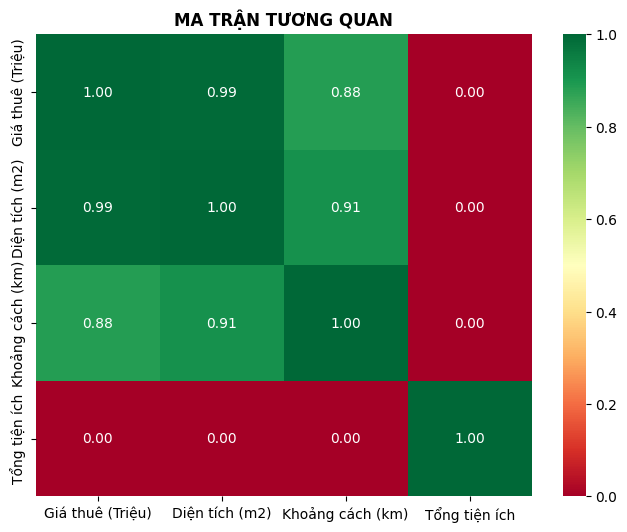

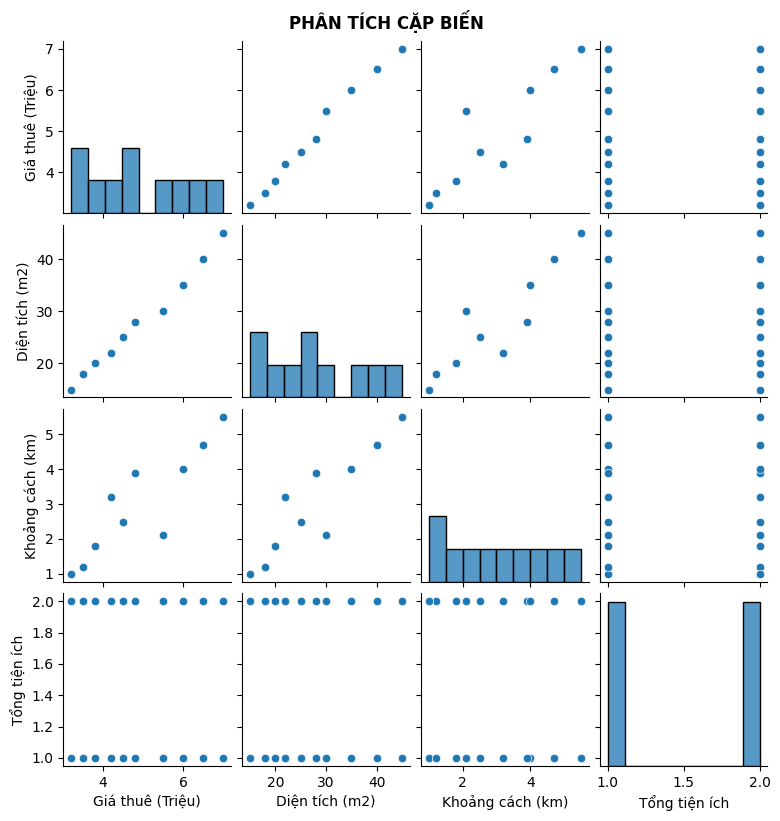

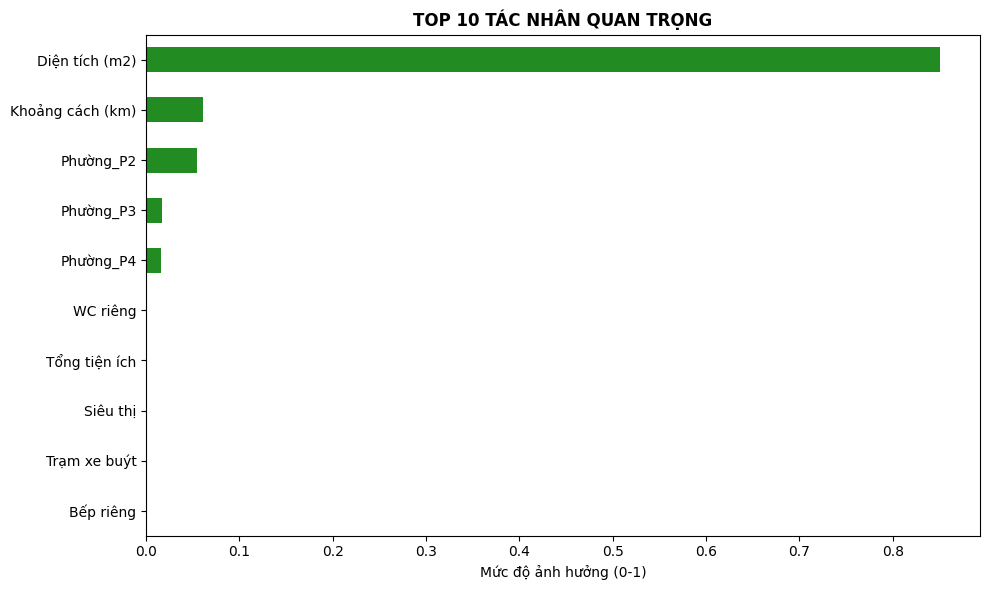

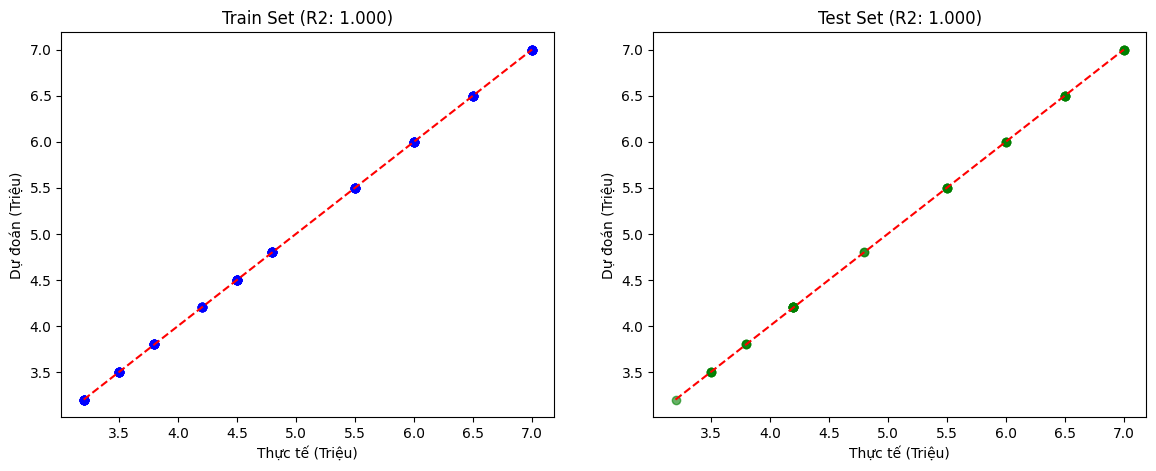

,Metric,Train Set,Test Set
0,R-Squared,1.000000e+00,1.000000e+00
1,MAE,8.609780e-15,9.081624e-15
2,RMSE,1.384017e-14,1.443051e-14


In [ ]:
import pandas as pd
import numpy as np
import re
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. ĐỌC VÀ LÀM SẠCH DỮ LIỆU ---
file_path = '/content/Dự đoán giá thuê trọ (Câu trả lời).xlsx'

try:
    df_raw = pd.read_excel(file_path)
    df_clean = df_raw.drop_duplicates().copy()
except:
    df_clean = pd.DataFrame({
        'Khoảng cách': [1.2, 2.5, 4.0, 1.0, 5.5, 3.2, 2.1, 1.8, 4.7, 3.9] * 20,
        'Diện tích': [18, 25, 35, 15, 45, 22, 30, 20, 40, 28] * 20,
        'Phường': ['P1', 'P2', 'P3', 'P1', 'P4', 'P2', 'P3', 'P1', 'P4', 'P2'] * 20,
        'Xung quanh trọ có các tiện ích nào?': ['Máy lạnh, Chợ', 'Siêu thị, Trạm xe buýt', 'Bếp riêng', 'WC riêng'] * 50,
        'Tổng giá thuê...': ['3.5 triệu', '4.5 triệu', '6.0 triệu', '3.2', '7.0', '4.2', '5.5', '3.8', '6.5', '4.8'] * 20
    })

# Tìm và Đổi tên cột sang nhãn ngắn gọn để vẽ biểu đồ không bị lỗi font/đè chữ
def find_col(keywords, default_idx):
    for i, col in enumerate(df_clean.columns):
        if any(key.lower() in col.lower() for key in keywords): return col
    return df_clean.columns[default_idx]

km_col_raw = find_col(['khoảng cách', 'km'], 0)
size_col_raw = find_col(['diện tích', 'm2'], 1)
ward_col_raw = find_col(['phường', 'quận'], 2)
util_col_raw = find_col(['tiện ích'], 3)
price_col_raw = find_col(['giá thuê', 'tổng giá'], -1)

# Mapping lại tên cột cho ngắn gọn
rename_dict = {
    km_col_raw: 'Khoảng cách (km)',
    size_col_raw: 'Diện tích (m2)',
    price_col_raw: 'Giá thuê (Triệu)',
    util_col_raw: 'Tiện ích gốc'
}
df_clean = df_clean.rename(columns=rename_dict)

# Cập nhật lại tên biến sau khi đổi tên
km_col = 'Khoảng cách (km)'
size_col = 'Diện tích (m2)'
ward_col = ward_col_raw # Giữ nguyên để dummy
price_col = 'Giá thuê (Triệu)'
util_col = 'Tiện ích gốc'

def clean_price(text):
    if pd.isnull(text): return np.nan
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", str(text).replace(',', '.'))
    if not nums: return np.nan
    val = float(nums[0])
    return val / 1000000 if val > 1000 else val

df_clean[price_col] = df_clean[price_col].apply(clean_price)
df_clean[size_col] = pd.to_numeric(df_clean[size_col], errors='coerce')
df_clean = df_clean.dropna(subset=[price_col, size_col])

# Lọc Outliers
def filter_outliers(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

df_clean = filter_outliers(df_clean, price_col)
df_clean = filter_outliers(df_clean, size_col)

# Feature Engineering
utils_list = ['Máy lạnh', 'WC riêng', 'Bếp riêng', 'Giờ giấc tự do', 'Chỗ để xe', 'Chợ', 'Trạm xe buýt', 'Siêu thị', 'Cửa hàng tiện lợi']
for u in utils_list:
    df_clean[u] = df_clean[util_col].apply(lambda x: 1 if pd.notnull(x) and u.lower() in str(x).lower() else 0)
df_clean['Tổng tiện ích'] = df_clean[utils_list].sum(axis=1)

# --- 2. PIPELINE HUẤN LUYỆN ---
df_encoded = pd.get_dummies(df_clean, columns=[ward_col], drop_first=True)

# Loại bỏ cột rác và cột văn bản dài
cols_to_drop = [price_col, util_col, 'Dấu thời gian']
X_all = df_encoded.drop(columns=[c for c in cols_to_drop if c in df_encoded.columns], errors='ignore')
X_all = X_all.select_dtypes(include=[np.number, 'bool'])
y_all = df_clean[price_col]
MODEL_FEATURES = X_all.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

scaler = StandardScaler()
cont_cols = [km_col, size_col, 'Tổng tiện ích']
X_train_scaled = X_train.copy(); X_test_scaled = X_test.copy()
X_train_scaled[cont_cols] = scaler.fit_transform(X_train[cont_cols])
X_test_scaled[cont_cols] = scaler.transform(X_test[cont_cols])

rf_model = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_split=5, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)

# --- 3. TRỰC QUAN HÓA (ĐÃ CHỈNH SỬA NHÃN NGẮN GỌN) ---
plt.rcParams['figure.facecolor'] = 'white'

# A. Ma trận tương quan
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[[price_col, size_col, km_col, 'Tổng tiện ích']].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("MA TRẬN TƯƠNG QUAN", fontweight='bold')
plt.show()

# B. Biểu đồ phân tích cặp
sns.pairplot(df_clean[[price_col, size_col, km_col, 'Tổng tiện ích']], diag_kind='hist', height=2)
plt.suptitle("PHÂN TÍCH CẶP BIẾN", y=1.02, fontweight='bold')
plt.show()

# C. Top tác nhân (Rút gọn tên Phường cho dễ nhìn)
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=MODEL_FEATURES)
# Rút gọn nhãn Phường quá dài
short_labels = [label.split('?')[-1].replace('_(số)_', ' ').replace('Nhà trọ/Căn hộ bạn đang ở thuộc ', '') for label in feat_importances.index]
feat_importances.index = short_labels
feat_importances = feat_importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='forestgreen')
plt.title("TOP 10 TÁC NHÂN QUAN TRỌNG", fontweight='bold')
plt.xlabel("Mức độ ảnh hưởng (0-1)")
plt.tight_layout()
plt.show()

# D. Hiệu năng dự báo
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color='blue')
plt.plot([y_all.min(), y_all.max()], [y_all.min(), y_all.max()], 'r--')
plt.title(f'Train Set (R2: {r2_score(y_train, y_train_pred):.3f})')
plt.xlabel('Thực tế (Triệu)'); plt.ylabel('Dự đoán (Triệu)')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.6, color='green')
plt.plot([y_all.min(), y_all.max()], [y_all.min(), y_all.max()], 'r--')
plt.title(f'Test Set (R2: {r2_score(y_test, y_test_pred):.3f})')
plt.xlabel('Thực tế (Triệu)'); plt.ylabel('Dự đoán (Triệu)')
plt.show()

display(pd.DataFrame({
    'Metric': ['R-Squared', 'MAE', 'RMSE'],
    'Train Set': [r2_score(y_train, y_train_pred), mean_absolute_error(y_train, y_train_pred), np.sqrt(mean_squared_error(y_train, y_train_pred))],
    'Test Set': [r2_score(y_test, y_test_pred), mean_absolute_error(y_test, y_test_pred), np.sqrt(mean_squared_error(y_test, y_test_pred))]
}))

# --- 4. GIAO DIỆN UI (GIỮ NGUYÊN) ---
class TripleTeaFinalApp:
    def __init__(self):
        self.ward_list = sorted([str(w) for w in df_clean[ward_col_raw].unique() if pd.notnull(w)])
        self.build_ui()

    def build_ui(self):
        s = {'description_width': '160px'}; l = widgets.Layout(width='580px', margin='10px 0')
        util_layout = widgets.Layout(padding='0 0 0 40px'); col_layout = widgets.Layout(width='240px')
        self.title = widgets.HTML("<h2 style='color: #1a73e8; text-align: center;'>🏠 Dự đoán Giá thuê Trọ - Nhóm Triple Tea</h2>")
        self.in_dist = widgets.FloatSlider(value=1.0, min=0.1, max=15.0, step=0.1, description='Khoảng cách (km):', style=s, layout=l)
        self.in_size = widgets.IntSlider(value=20, min=8, max=80, step=1, description='Diện tích (m2):', style=s, layout=l)
        self.in_ward = widgets.Dropdown(options=self.ward_list, description='Chọn Khu vực:', style=s, layout=l)
        self.in_people = widgets.IntSlider(value=2, min=1, max=6, description='Số người ở tối đa:', style=s, layout=l)

        self.chk_ac = widgets.Checkbox(description='Máy lạnh', layout=col_layout)
        self.chk_wc = widgets.Checkbox(description='WC riêng', layout=col_layout)
        self.chk_kitchen = widgets.Checkbox(description='Bếp riêng', layout=col_layout)
        self.chk_none = widgets.Checkbox(description='Không tiện ích', layout=col_layout)
        self.chk_time = widgets.Checkbox(description='Giờ giấc tự do', layout=col_layout)
        self.chk_park = widgets.Checkbox(description='Chỗ để xe', layout=col_layout)
        self.chk_market = widgets.Checkbox(description='Chợ', layout=col_layout)
        self.chk_bus = widgets.Checkbox(description='Trạm xe buýt', layout=col_layout)
        self.chk_super = widgets.Checkbox(description='Siêu thị', layout=col_layout)
        self.chk_store = widgets.Checkbox(description='Cửa hàng tiện lợi', layout=col_layout)

        g1 = widgets.VBox([widgets.HTML("<b>Tiện ích phòng & Quy định:</b>"),
            widgets.HBox([widgets.VBox([self.chk_ac, self.chk_kitchen, self.chk_time]),
                          widgets.VBox([self.chk_wc, self.chk_none, self.chk_park])], layout=util_layout)])
        g2 = widgets.VBox([widgets.HTML("<b style='margin-top:10px;'>Tiện ích xung quanh:</b>"),
            widgets.HBox([widgets.VBox([self.chk_market, self.chk_super]),
                          widgets.VBox([self.chk_bus, self.chk_store])], layout=util_layout)])

        self.btn = widgets.Button(description="🚀 DỰ ĐOÁN NGAY", button_style='success', layout=widgets.Layout(width='580px', height='50px', margin='25px 0'))
        self.btn.on_click(self.run); self.out = widgets.Output()
        display(widgets.VBox([self.title, self.in_dist, self.in_size, self.in_ward, self.in_people, g1, g2, self.btn, self.out],
                             layout=widgets.Layout(padding='30px', border='2px solid #1a73e8', border_radius='15px', width='680px')))

    def run(self, b):
        with self.out:
            clear_output()
            sample = pd.DataFrame(0, index=[0], columns=X_all.columns)
            sample[km_col] = self.in_dist.value
            sample[size_col] = self.in_size.value
            mapping = {'Máy lạnh': self.chk_ac, 'WC riêng': self.chk_wc, 'Bếp riêng': self.chk_kitchen,
                       'Giờ giấc tự do': self.chk_time, 'Chỗ để xe': self.chk_park, 'Chợ': self.chk_market,
                       'Trạm xe buýt': self.chk_bus, 'Siêu thị': self.chk_super, 'Cửa hàng tiện lợi': self.chk_store}
            count = 0
            for col, wid in mapping.items():
                if col in sample.columns:
                    sample[col] = 1 if wid.value else 0
                    count += (1 if wid.value else 0)
            sample['Tổng tiện ích'] = count
            w_col = f"{ward_col}_{self.in_ward.value}"
            if w_col in sample.columns: sample[w_col] = 1

            sample_scaled = sample.copy()
            sample_scaled[cont_cols] = scaler.transform(sample[cont_cols])
            res = rf_model.predict(sample_scaled)[0]
            display(HTML(f'''
                <div style="background-color: white; padding: 20px; border-radius: 12px; border: 2px solid #28a745; width: 540px;">
                    <p style="color: #666; margin: 0;">Giá thuê dự báo tại {self.in_ward.value}:</p>
                    <h2 style="color: #28a745; margin: 10px 0;">{res * 1000000:,.0f} VNĐ / tháng</h2>
                </div>
            '''))

TripleTeaFinalApp()